# Task 1 - Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.signal import savgol_filter

In [2]:
file_path = 'NIR_Data.xlsx'
df = pd.read_excel(file_path)
df

,Sample ID,Unnamed: 1,11988.51,11980.8,11973.08,11965.37,11957.66,11949.94,11942.23,11934.51,...,4057.888,4050.173,4042.459,4034.744,4027.03,4019.315,4011.601,4003.886,3996.171,Moisture
0,3001RanBioMixMalarenergi.0,1,0.430391,0.430351,0.430570,0.430974,0.431129,0.430807,0.430425,0.430264,...,1.042346,1.052940,1.062511,1.070474,1.077419,1.082571,1.084933,1.086961,1.088756,24.933532
1,3001RanBioMixMalarenergi.1,2,0.418378,0.418387,0.418783,0.418983,0.418721,0.418339,0.417951,0.417494,...,1.017335,1.027128,1.036592,1.043992,1.049032,1.051711,1.052812,1.054065,1.055364,24.933532
2,3001RanBioMixMalarenergi.2,3,0.446782,0.446930,0.446840,0.446419,0.446009,0.445715,0.445539,0.445537,...,1.053265,1.061849,1.070649,1.079960,1.088810,1.094708,1.098719,1.100796,1.099144,24.933532
3,3001RanBioMixMalarenergi.3,4,0.434038,0.433805,0.433692,0.433850,0.433912,0.433757,0.433515,0.433327,...,1.020629,1.029372,1.038613,1.047470,1.053009,1.054695,1.054589,1.053924,1.053708,24.933532
4,3001RanBioMixMalarenergi.4,5,0.451491,0.451441,0.451692,0.451816,0.451755,0.451595,0.451293,0.451114,...,1.013404,1.023107,1.030855,1.036464,1.042622,1.049984,1.055300,1.055122,1.052386,24.933532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,3154RanBioMixMalarenergi.1,945,0.340521,0.340076,0.339782,0.339961,0.340233,0.340201,0.339958,0.339772,...,1.012959,1.023482,1.032525,1.040089,1.044798,1.047819,1.047905,1.046299,1.045034,39.039775
769,3154RanBioMixMalarenergi.2,946,0.369337,0.368663,0.367986,0.367705,0.367920,0.368156,0.368237,0.368364,...,0.958066,0.967192,0.973893,0.978803,0.982503,0.985984,0.987628,0.988656,0.987488,39.039775
770,3154RanBioMixMalarenergi.3,947,0.414796,0.414180,0.413598,0.413055,0.413093,0.413714,0.414176,0.414099,...,1.037804,1.047028,1.054885,1.060705,1.066238,1.071721,1.073868,1.073359,1.073496,39.039775
771,3154RanBioMixMalarenergi.4,948,0.353829,0.353229,0.352726,0.352591,0.352698,0.352684,0.352596,0.352764,...,1.089022,1.099540,1.110634,1.119961,1.126208,1.130563,1.136066,1.142062,1.143006,39.039775


In [3]:
df.shape

(773, 1040)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Columns: 1040 entries, Sample ID to Moisture
dtypes: float64(1038), int64(1), object(1)
memory usage: 6.1+ MB


In [5]:
df.describe()

,Unnamed: 1,11988.51,11980.8,11973.08,11965.37,11957.66,11949.94,11942.23,11934.51,11926.8,...,4057.888,4050.173,4042.459,4034.744,4027.03,4019.315,4011.601,4003.886,3996.171,Moisture
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,...,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,408.213454,0.555737,0.555510,0.555277,0.555048,0.554840,0.554626,0.554355,0.554071,0.553910,...,1.317717,1.329259,1.340147,1.350056,1.358602,1.366028,1.371983,1.376410,1.379461,45.923968
std,248.050920,0.175660,0.175460,0.175265,0.175117,0.174975,0.174754,0.174469,0.174225,0.174044,...,0.340964,0.342912,0.345109,0.347525,0.349551,0.351773,0.354764,0.358255,0.361254,14.438512
min,1.000000,0.267237,0.267553,0.267540,0.267290,0.267120,0.267273,0.267674,0.267835,0.267568,...,0.834207,0.844301,0.854448,0.863110,0.869628,0.872326,0.869916,0.865599,0.864294,17.981283
25%,200.000000,0.420672,0.420877,0.421411,0.421568,0.421270,0.420521,0.419843,0.419885,0.420369,...,1.024053,1.034605,1.042483,1.050190,1.056983,1.061127,1.065872,1.068472,1.069060,32.701132
50%,393.000000,0.499081,0.498969,0.498818,0.498389,0.497959,0.497896,0.497825,0.497684,0.497610,...,1.152513,1.162409,1.171408,1.180406,1.188808,1.196223,1.202620,1.209910,1.212224,46.633770
75%,598.000000,0.687495,0.687133,0.687137,0.686687,0.685944,0.685141,0.684693,0.684451,0.684272,...,1.620539,1.634250,1.641243,1.655206,1.668228,1.674807,1.682464,1.687439,1.695434,57.791259
max,949.000000,0.978465,0.977729,0.975623,0.973480,0.972385,0.972466,0.972688,0.971705,0.970126,...,2.127790,2.150049,2.165036,2.179036,2.216297,2.240847,2.241775,2.271550,2.314094,73.066950


In [6]:
df = df.drop(columns=['Unnamed: 1'])

In [7]:
# Check for null values
print(df.isnull().sum().unique()) # no null values

# Check for duplicates
print(df.duplicated().sum()) # no duplicates

[0]
0


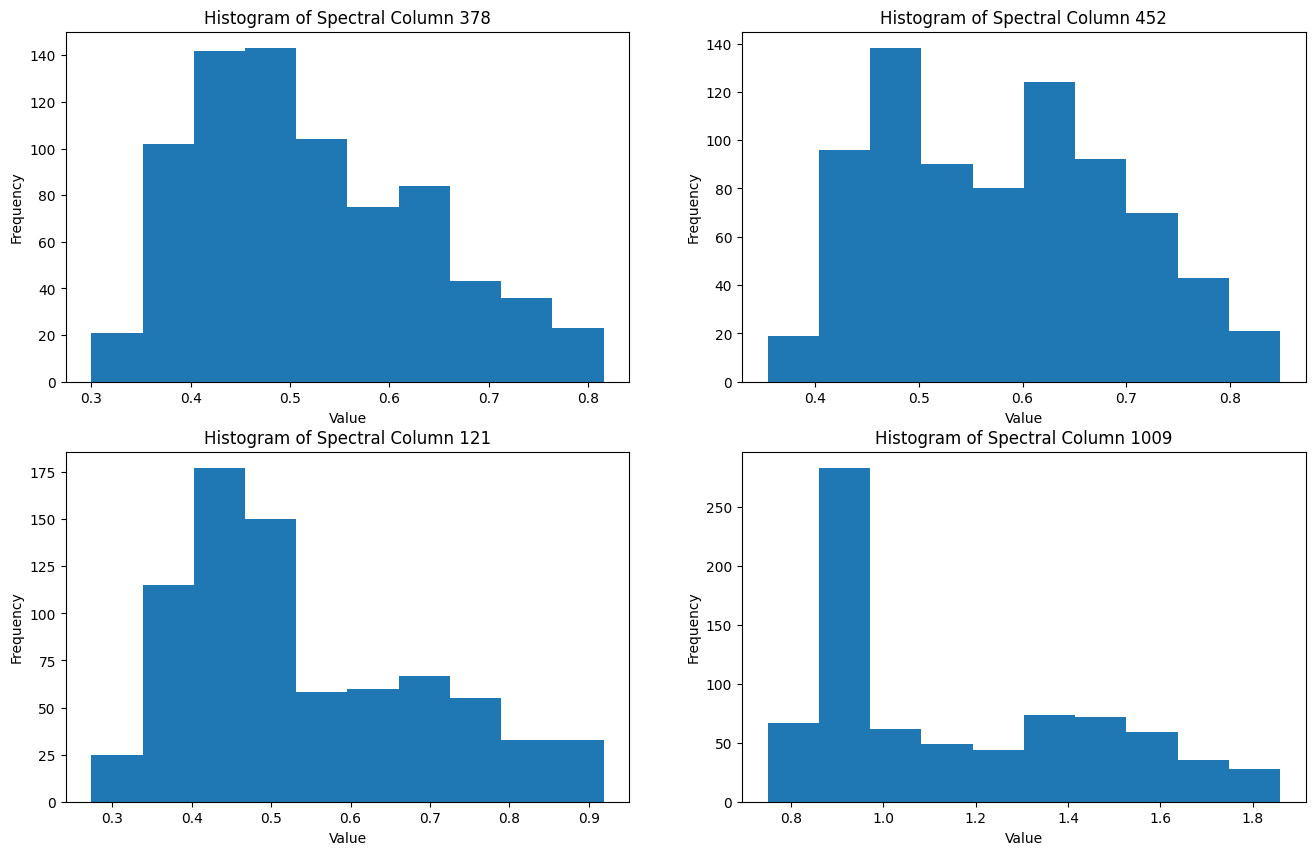

In [ ]:
# Histograms of 4 random spectral columns
spectral_column_indeces = [random.randint(0, df.shape[1] - 2) for _ in range(4)]

plt.figure(figsize=(16, 10))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.hist(df.iloc[:, spectral_column_indeces[i]])
    plt.title(f'Histogram of Spectral Column {spectral_column_indeces[i]}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.show()

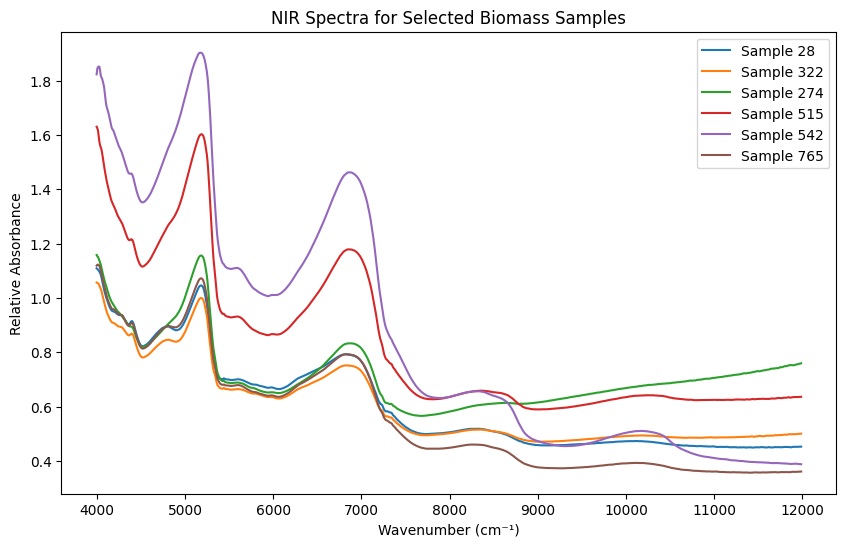

In [ ]:
# Spectogram of 6 random spectral columns
spectral_row_indeces = [random.randint(0, df.shape[0] - 1) for _ in range(6)]

spectral_columns = df.columns[1:-1]

plt.figure(figsize=(10, 6))
for i in spectral_row_indeces:
    spectrum = df.iloc[i, 1:-1].values.astype(float)
    plt.plot(spectral_columns, spectrum, label=f"Sample {i}")

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Relative Absorbance")
plt.title("NIR Spectra for Selected Biomass Samples")
plt.legend()
plt.show()

In [8]:
# Outlier detection
for column in df.columns[1:-1]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if not outliers.empty:
      print(f"Outliers in column '{column}':")
      print(outliers)

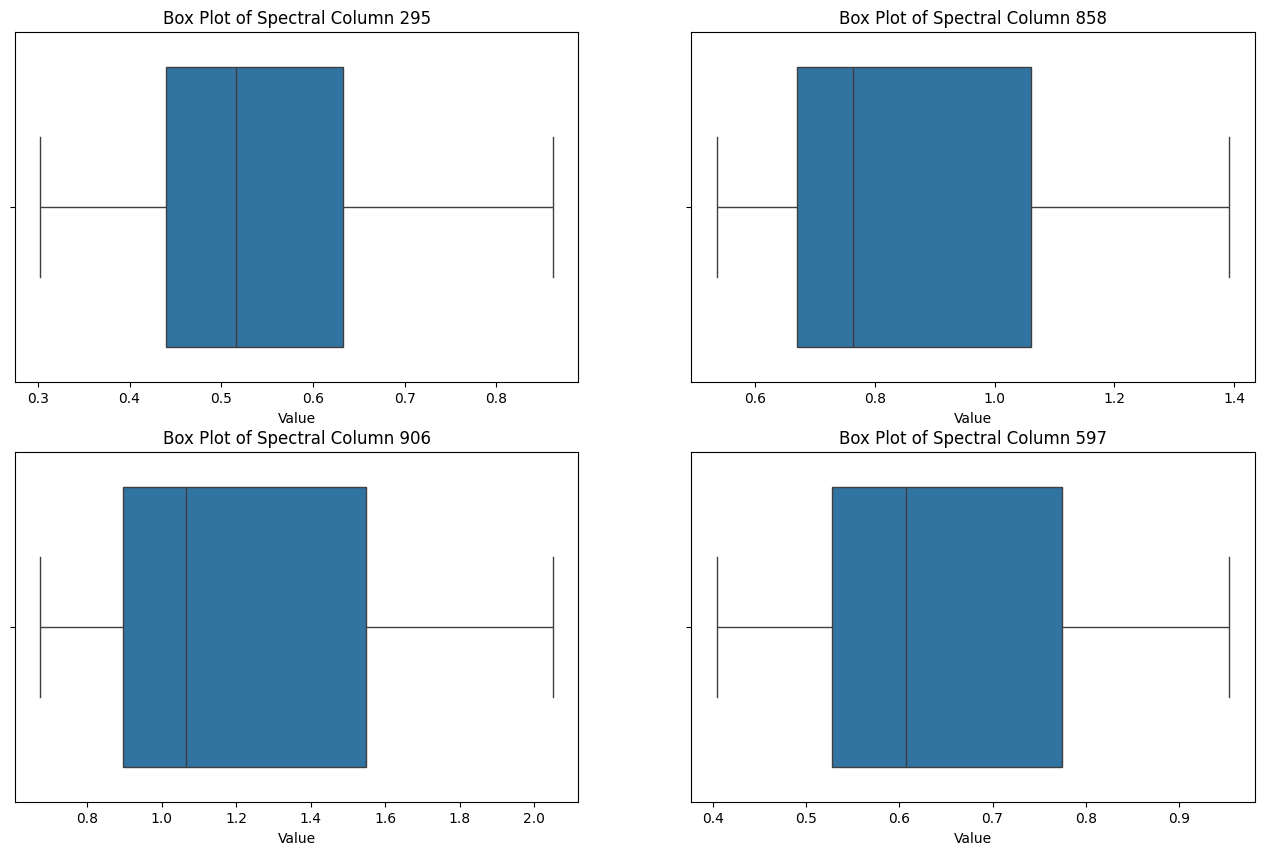

In [ ]:
# Box plots for outlier detection
spectral_column_indeces = [random.randint(0, df.shape[1] - 2) for _ in range(4)]

plt.figure(figsize=(16, 10))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df.iloc[:, spectral_column_indeces[i]])
    plt.title(f'Box Plot of Spectral Column {spectral_column_indeces[i]}')
    plt.xlabel('Value')

plt.show()

In [ ]:
# Correlation values
target = df['Moisture']
correlation_matrix = df.drop(columns=['Moisture', 'Sample ID']).corrwith(target)
top_5_features = correlation_matrix.abs().nlargest(5)
print(top_5_features)

5114.791    0.899023
5122.505    0.899021
5107.076    0.898987
5130.220    0.898978
5099.361    0.898928
dtype: float64


In [10]:
# Prepare a figure to compare preprocessing methods for the first sample
sample_index = random.randint(0, df.shape[0] - 1)
spectral_columns = df.columns[1:-1]
original_spectrum = df.loc[sample_index, spectral_columns].values.astype(float)

In [11]:
# Define a function for Standard Normal Variate (SNV) transformation
def snv_transform(spectrum):
    mean = np.mean(spectrum)
    std = np.std(spectrum)
    return (spectrum - mean) / std

snv_spectrum = snv_transform(original_spectrum)

In [12]:
# Define a function for Multiplicative Scatter Correction (MSC) transformation
def msc_transform(spectrum, ref_spectrum):
    coeffs = np.polyfit(ref_spectrum, spectrum, deg=1)
    return (spectrum - coeffs[1]) / coeffs[0]

ref_spectrum = np.mean(df[spectral_columns].values, axis=0)
msc_spectrum = msc_transform(original_spectrum, ref_spectrum)

In [13]:
# Define parameters for the Savitzky-Golay filter
window_length = 11  # should be an odd number
polyorder = 2

# Apply Savitzky-Golay smoothing
savgol_spectrum = savgol_filter(original_spectrum, window_length=window_length, polyorder=polyorder, deriv=0)

# Apply Savitzky-Golay for first derivative
savgol_deriv = savgol_filter(original_spectrum, window_length=window_length, polyorder=polyorder, deriv=1)

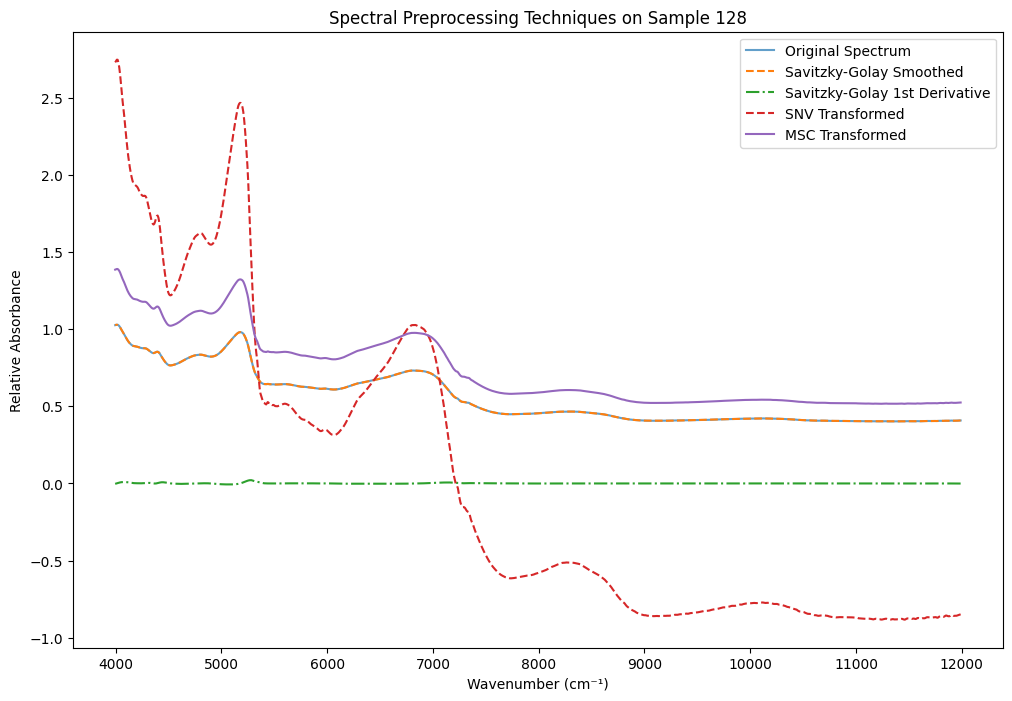

In [14]:
# Plot the original and preprocessed spectra
plt.figure(figsize=(12, 8))
plt.plot(spectral_columns, original_spectrum, label='Original Spectrum', alpha=0.7)
plt.plot(spectral_columns, savgol_spectrum, label='Savitzky-Golay Smoothed', linestyle='--')
plt.plot(spectral_columns, savgol_deriv, label='Savitzky-Golay 1st Derivative', linestyle='-.')
plt.plot(spectral_columns, snv_spectrum, label='SNV Transformed', linestyle='--')
plt.plot(spectral_columns, msc_spectrum, label='MSC Transformed', linestyle='-')
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Relative Absorbance")
plt.title("Spectral Preprocessing Techniques on Sample {}".format(sample_index))
plt.legend()
plt.show()

# Task 2 - Model Training

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import r2_score, mean_squared_error
from scipy.signal import savgol_filter

In [16]:
# First transofrmation is Savitzky-Golay smoothing
class SavgolFilter(BaseEstimator, TransformerMixin):
    """
    Custom transformer to apply Savitzky-Golay filtering on each row (spectrum).
    """
    def __init__(self, window_length=11, polyorder=3, deriv=0):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv

    def fit(self, X, y=None):
        # No fitting required for this filter
        return self

    def transform(self, X):
        # Apply Savitzky-Golay filter to each row in X
        X_sg = np.apply_along_axis(
            lambda row: savgol_filter(row,
                                      window_length=self.window_length,
                                      polyorder=self.polyorder,
                                      deriv=self.deriv),
            axis=1,
            arr=X
        )
        return X_sg

# Second transformation is Standard normal variate
class SNV(BaseEstimator, TransformerMixin):
    """
    Custom transformer to apply Standard Normal Variate (SNV) to each row (spectrum).
    """
    def fit(self, X, y=None):
        # No fitting required for SNV
        return self

    def transform(self, X):
        # For each row, subtract mean and divide by std
        means = X.mean(axis=1, keepdims=True)
        stds = X.std(axis=1, keepdims=True)
        X_snv = (X - means) / stds
        return X_snv

# Third transformation is Multiplicative Scatter Correction
class MSC(BaseEstimator, TransformerMixin):
    """
    Multiplicative Scatter Correction (MSC) Transformer for spectral data.
    """
    def fit(self, X, y=None):
        # Compute the mean spectrum to use as the reference
        self.ref_spectrum_ = np.mean(X, axis=0)
        return self

    def transform(self, X):
        """
        Apply MSC transformation to the spectral data.
        """
        X_msc = np.zeros_like(X)

        for i in range(X.shape[0]):
            spectrum = X[i, :]
            # Fit linear regression between the spectrum and the reference spectrum
            coeffs = np.polyfit(self.ref_spectrum_, spectrum, deg=1)
            # Correct the spectrum using the fitted coefficients
            X_msc[i, :] = (spectrum - coeffs[1]) / coeffs[0]

        return X_msc

In [17]:
X = df[spectral_columns].values.astype(float)
y = df['Moisture'].values.astype(float)

X.shape, y.shape

((773, 1037), (773,))

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((618, 1037), (155, 1037), (618,), (155,))

In [20]:
def train_model(pipeline):
  pipeline.fit(X_train, y_train)
  y_pred = pipeline.predict(X_test)

  cv_r2 = cross_val_score(pipeline, X, y, cv=5, scoring='r2').mean()
  cv_rmse = cross_val_score(pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error').mean()

  print("Cross-validation R² scores:", cv_r2)
  print("Cross-validation RMSE scores:", -cv_rmse)

  return cv_r2, -cv_rmse, y_pred

def search_grid(pipeline, param_grid):
  grid_search = GridSearchCV(pipeline1, param_grid, cv=5, scoring=['r2', 'neg_root_mean_squared_error'], refit='r2')
  grid_search.fit(X_train, y_train)

  print("Best parameters found: ", grid_search.best_params_)

In [ ]:
results = pd.DataFrame(columns=['Model', 'Preprocessing', 'R²', 'RMSE'])

## Partial Least Squares Model (PLS)

In [ ]:
n_components = 20

pipeline1 = Pipeline([
    ('savgol', SavgolFilter(window_length=11, polyorder=2, deriv=0)),
    ('regressor', PLSRegression(n_components=n_components))
])

pipeline2 = Pipeline([
    ('snv', SNV()),
    ('regressor', PLSRegression(n_components=n_components))
])

pipeline3 = Pipeline([
    ('msc', MSC()),
    ('regressor', PLSRegression(n_components=n_components))
])

pls_param_grid = {
    'regressor__n_components': [5, 10, 15, 20]
}

# search_grid(pipeline1, pls_param_grid)
# search_grid(pipeline2, pls_param_grid)
# search_grid(pipeline3, pls_param_grid)

cv_r2_1, cv_rmse_1, y_pred_pls_1 = train_model(pipeline1)
cv_r2_2, cv_rmse_2, y_pred_pls_2 = train_model(pipeline2)
cv_r2_3, cv_rmse_3, y_pred_pls_3 = train_model(pipeline3)

results.loc[len(results)] = ['PLS', 'Savitzky-Golay', cv_r2_1, cv_rmse_1]
results.loc[len(results)] = ['PLS', 'SNV', cv_r2_2, cv_rmse_2]
results.loc[len(results)] = ['PLS', 'MSC', cv_r2_3, cv_rmse_3]

Cross-validation R² scores: 0.9075761614046473
Cross-validation RMSE scores: 3.278608682533961
Cross-validation R² scores: 0.9216427243458508
Cross-validation RMSE scores: 2.9374607615557315
Cross-validation R² scores: 0.9127233584618238
Cross-validation RMSE scores: 3.10311115300284


## Support Vector Regression (SVR)

In [ ]:
C = 200
epsilon = 0.1

pipeline1 = Pipeline([
    ('savgol', SavgolFilter(window_length=11, polyorder=2, deriv=0)),
    ('regressor', SVR(C=C, epsilon=epsilon))
])

pipeline2 = Pipeline([
    ('snv', SNV()),
    ('regressor', SVR(C=C, epsilon=epsilon))
])

pipeline3 = Pipeline([
    ('msc', MSC()),
    ('regressor', SVR(C=C, epsilon=epsilon))
])

svr_param_grid = {
    'regressor__C': [0.1, 1, 10, 100, 200],
    'regressor__epsilon': [0.01, 0.1, 0.5, 1]
}

# search_grid(pipeline1, svr_param_grid)
# search_grid(pipeline2, svr_param_grid)
# search_grid(pipeline3, svr_param_grid)

cv_r2_1, cv_rmse_1, y_pred_svr_1 = train_model(pipeline1)
cv_r2_2, cv_rmse_2, y_pred_svr_2 = train_model(pipeline2)
cv_r2_3, cv_rmse_3, y_pred_svr_3 = train_model(pipeline3)

results.loc[len(results)] = ['SVR', 'Savitzky-Golay', cv_r2_1, cv_rmse_1]
results.loc[len(results)] = ['SVR', 'SNV', cv_r2_2, cv_rmse_2]
results.loc[len(results)] = ['SVR', 'MSC', cv_r2_3, cv_rmse_3]

Cross-validation R² scores: 0.7879856079535926
Cross-validation RMSE scores: 5.113743263836218
Cross-validation R² scores: 0.8792717121247818
Cross-validation RMSE scores: 3.8417419489968196
Cross-validation R² scores: 0.8803009340407076
Cross-validation RMSE scores: 3.8418751001971074


## Artifical Neural Network (ANN)

In [ ]:
max_iter = 1000
alpha = 0.001
hidden_layer_sizes = (100, 50)
learning_rate_init = 0.001

pipeline1 = Pipeline([
    ('savgol', SavgolFilter(window_length=11, polyorder=2, deriv=0)),
    ('regressor', MLPRegressor(max_iter=max_iter, alpha=alpha, hidden_layer_sizes=hidden_layer_sizes, learning_rate_init=learning_rate_init))
])

pipeline2 = Pipeline([
    ('snv', SNV()),
    ('regressor', MLPRegressor(max_iter=max_iter, alpha=0.0001, hidden_layer_sizes=hidden_layer_sizes, learning_rate_init=learning_rate_init))
])

pipeline3 = Pipeline([
    ('msc', MSC()),
    ('regressor', MLPRegressor(max_iter=max_iter, alpha=0.0001, hidden_layer_sizes=hidden_layer_sizes, learning_rate_init=learning_rate_init))
])

ann_param_grid = {
    'regressor__hidden_layer_sizes': [(100,), (100, 50)],
    'regressor__alpha': [0.0001, 0.001],
    'regressor__learning_rate_init': [0.001, 0.01]
}

# search_grid(pipeline1, ann_param_grid)
# search_grid(pipeline2, ann_param_grid)
# search_grid(pipeline3, ann_param_grid)

cv_r2_1, cv_rmse_1, y_pred_ann_1 = train_model(pipeline1)
cv_r2_2, cv_rmse_2, y_pred_ann_2 = train_model(pipeline2)
cv_r2_3, cv_rmse_3, y_pred_ann_3 = train_model(pipeline3)

results.loc[len(results)] = ['ANN', 'Savitzky-Golay', cv_r2_1, cv_rmse_1]
results.loc[len(results)] = ['ANN', 'SNV', cv_r2_2, cv_rmse_2]
results.loc[len(results)] = ['ANN', 'MSC', cv_r2_3, cv_rmse_3]

Cross-validation R² scores: 0.6571086645574056
Cross-validation RMSE scores: 6.15165263215962
Cross-validation R² scores: 0.866512138564629
Cross-validation RMSE scores: 4.372195850790689
Cross-validation R² scores: 0.7901971799069574
Cross-validation RMSE scores: 5.099448345458289


# Task 3 - Comparing results

In [ ]:
# Visualizing result
def plot_results(y_pred, y_true, model_name):
  sns.scatterplot(x=y_true, y=y_pred, alpha=0.7, edgecolor='k')

  # Plot y = x line
  min_val = min(min(y_true), min(y_pred))
  max_val = max(max(y_true), max(y_pred))
  plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", label="Ideal Fit (y = x)")

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"{model_name} - Predictions vs. Actual")
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
# Best performing models by R2
results.sort_values(by='R²', ascending=False)

,Model,Preprocessing,R²,RMSE
1,PLS,SNV,0.921643,2.937461
2,PLS,MSC,0.912723,3.103111
0,PLS,Savitzky-Golay,0.907576,3.278609
5,SVR,MSC,0.880301,3.841875
4,SVR,SNV,0.879272,3.841742
7,ANN,SNV,0.866512,4.372196
8,ANN,MSC,0.790197,5.099448
3,SVR,Savitzky-Golay,0.787986,5.113743
6,ANN,Savitzky-Golay,0.657109,6.151653


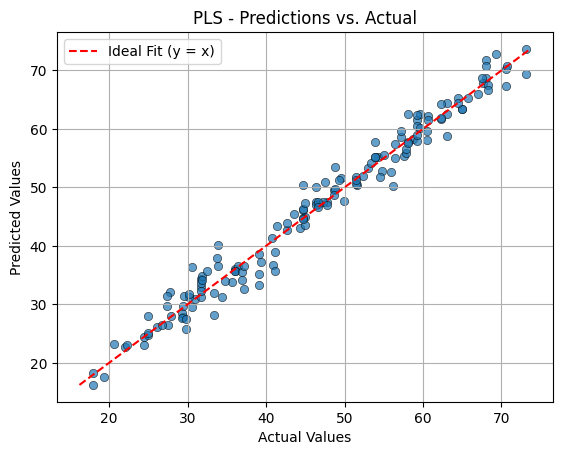

In [ ]:
# Best perfoming model for Partial Least Squares is with SVN preprocessing
plot_results(y_pred_pls_2, y_test, 'PLS')

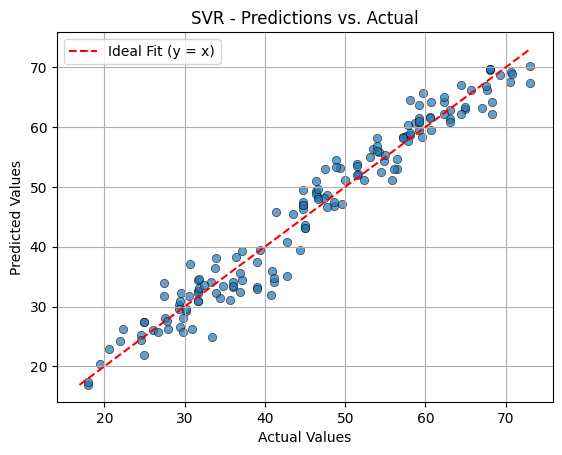

In [ ]:
# Best perfoming model for Support Vector Regressor is with MSC preprocessing
plot_results(y_pred_svr_3, y_test, 'SVR')

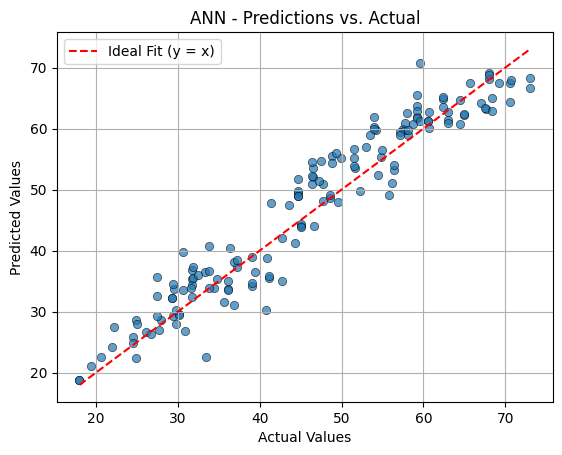

In [ ]:
# Best perfoming model for Artifical Neural Network is with SVN preprocessing
plot_results(y_pred_ann_2, y_test, 'ANN')